In [1]:
import os
import matplotlib.pyplot as plt
import torch
from torch.amp import autocast
from v1_model import ContinuousMotionModel
from torch.utils.data import DataLoader
from dataset.dataset import *
import utils.utils as utils
from datetime import datetime

In [ ]:
# Get the newest model from the directory. That means find the newest folder, and then the newest file in that folder.
model_path = utils.get_latest_model_path("v1_models_sweeped/sliding_vs_normal_models/normal") # or v1_models
print(f"Model path: {model_path}")

# Load the model
model: ContinuousMotionModel = ContinuousMotionModel.load_model(model_path, utils.get_device())
model.condition_mask_probabilty = 0.0  # Disable condition mask probability for inference
model = model.to(utils.get_device())

num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters in the model: {num_params}")

device = utils.get_device()

Model path: v1_models_sweeped/sliding_vs_normal_models/normal/_normal_diffusion_seed_1__gsott0in/_normal_diffusion_seed_1__gsott0in_epoch_1601.pth
Number of parameters in the model: 8514585


In [4]:
model

ContinuousMotionModel(
  (timestep_mlp): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
  )
  (style_linear): Linear(in_features=17, out_features=64, bias=True)
  (seed_linear): Linear(in_features=0, out_features=192, bias=True)
  (audio_linear): Linear(in_features=37, out_features=64, bias=True)
  (noisy_gesture_linear): Linear(in_features=345, out_features=256, bias=True)
  (pre_local_attention_linear): Linear(in_features=576, out_features=256, bias=True)
  (multi_head_local_attention): LocalMHA(
    (to_qkv): Linear(in_features=256, out_features=768, bias=False)
    (attn_fn): LocalAttention(
      (dropout): Dropout(p=0.0, inplace=False)
      (rel_pos): SinusoidalEmbeddings()
    )
    (to_out): Linear(in_features=256, out_features=256, bias=False)
  )
  (relative_positional_embedding_funtion): SinusoidalEmbeddings()
  (transformer_encoder): TransformerEncoder(
    (layers): Modu

In [5]:
val_loader = DataLoader(
        GPUDataset(
            consolidated_file = "dataset/genea2023_dataset/val/main-agent/consolidated.npz",
            seq_length = 70,
            seed_length = 0,
            batch_size = 64,
            epoch_length = 30,
            loading_encoded_data = False,
            include_vel_acc_features = False,
            device = device
        ),
        batch_size = 1,
        num_workers = 0,
        pin_memory = False
    )

Initializing GPU-resident dataset on cpu
Loading data from dataset/genea2023_dataset/val/main-agent/consolidated.npz directly to GPU...
Data loaded to GPU. Gesture shape: torch.Size([75600, 345]), Audio shape: torch.Size([75600, 37])
Found 72771 valid starting points for windows
Dataset initialization complete!


In [6]:
def compute_average_error_matrix(predictions, ground_truths):
    
    assert predictions.shape == ground_truths.shape, "Shape mismatch between predictions and ground truths"
    
    # Compute absolute difference per element
    abs_diff = torch.abs(predictions - ground_truths)  # Shape: (batch_size, *dims)
    
    # Average over the batch dimension
    avg_error_matrix = abs_diff.mean(dim=0)  # Shape: (*dims)
    
    return avg_error_matrix

In [7]:
def visualize_error_matrix(error_matrix, save_dir, filename="average_error.png", cmap="hot"):
    if isinstance(error_matrix, torch.Tensor):
        error_matrix = error_matrix.cpu().numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(error_matrix, cmap=cmap, interpolation='nearest')
    plt.title("Average Per-Pixel Absolute Error")
    plt.colorbar()
    plt.tight_layout()
    plt.close()



In [8]:
def visualize_and_save_error_matrix(error_matrix, save_dir, filename="average_error.png", cmap="hot"):
    if isinstance(error_matrix, torch.Tensor):
        error_matrix = error_matrix.cpu().numpy()

    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, filename)

    plt.figure(figsize=(6, 6))
    plt.imshow(error_matrix, cmap=cmap, interpolation='nearest')
    plt.title("Average Per-Pixel Absolute Error")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

    print(f"Saved error visualization to {save_path}")

In [10]:
all_outputs = []
all_ground_truths = []

with torch.no_grad():
    for val_batch in val_loader:
        gesture_sequence, gesture_seed, audio_features, main_agent_id_one_hot = [
            item.squeeze(0).to(device) for item in val_batch
        ]

        print(f"Processing batch with gesture_sequence shape: {gesture_sequence.shape}, "
              f"gesture_seed shape: {gesture_seed.shape}, "
              f"audio_features shape: {audio_features.shape}, "
              f"main_agent_id_one_hot shape: {main_agent_id_one_hot.shape}")
        
        output, encoded_gesture_sequence, encoded_output, noisy_gesture_sequence = model.generate(
            gesture_sequence            = gesture_sequence,
            audio_features              = audio_features,
            main_agent_id_one_hot       = main_agent_id_one_hot,
            gesture_seed                = gesture_seed,
            gesture_sequence_is_encoded = val_loader.dataset.loading_encoded_data
        )

        print(f"Output shape: {output.shape}")
        # print(output)
        
        all_outputs.append(output.cpu())
        all_ground_truths.append(gesture_sequence.cpu())

Processing batch with gesture_sequence shape: torch.Size([64, 70, 345]), gesture_seed shape: torch.Size([64, 0, 345]), audio_features shape: torch.Size([64, 70, 37]), main_agent_id_one_hot shape: torch.Size([64, 17])
Output shape: torch.Size([64, 70, 345])
Processing batch with gesture_sequence shape: torch.Size([64, 70, 345]), gesture_seed shape: torch.Size([64, 0, 345]), audio_features shape: torch.Size([64, 70, 37]), main_agent_id_one_hot shape: torch.Size([64, 17])
Output shape: torch.Size([64, 70, 345])
Processing batch with gesture_sequence shape: torch.Size([64, 70, 345]), gesture_seed shape: torch.Size([64, 0, 345]), audio_features shape: torch.Size([64, 70, 37]), main_agent_id_one_hot shape: torch.Size([64, 17])
Output shape: torch.Size([64, 70, 345])
Processing batch with gesture_sequence shape: torch.Size([64, 70, 345]), gesture_seed shape: torch.Size([64, 0, 345]), audio_features shape: torch.Size([64, 70, 37]), main_agent_id_one_hot shape: torch.Size([64, 17])
Output shape

In [11]:
all_outputs


[tensor([[[ 1.3281e+00, -3.4766e-01,  6.5234e-01,  ..., -1.3750e+00,
            7.0312e-01, -1.8164e-01],
          [ 1.3906e+00, -2.7539e-01,  5.5859e-01,  ..., -1.3359e+00,
            7.1875e-01, -2.2070e-01],
          [ 1.2812e+00, -4.3164e-01,  6.0547e-01,  ..., -1.3203e+00,
            7.1094e-01, -2.3535e-01],
          ...,
          [ 1.1797e+00, -6.0156e-01,  3.4570e-01,  ..., -1.1328e+00,
            7.1094e-01, -3.6523e-01],
          [ 1.1953e+00, -5.7812e-01,  4.5312e-01,  ..., -1.0625e+00,
            7.2266e-01, -3.3398e-01],
          [ 1.1250e+00, -5.8984e-01,  2.0605e-01,  ..., -1.0078e+00,
            6.7969e-01, -2.5195e-01]],
 
         [[-9.8047e-01, -1.0791e-01, -2.1875e+00,  ...,  1.1953e+00,
           -6.0938e-01,  4.8047e-01],
          [-9.8047e-01,  1.5106e-03, -2.4844e+00,  ...,  1.0938e+00,
           -3.7891e-01,  2.8711e-01],
          [-8.5938e-01,  6.1035e-02, -2.2344e+00,  ...,  7.8906e-01,
           -1.3477e-01,  5.4199e-02],
          ...,
    

In [12]:
all_ground_truths

[tensor([[[ 1.6706, -0.8606,  0.6621,  ..., -1.4833,  0.7032, -0.4172],
          [ 1.6835, -1.0048,  0.6421,  ..., -1.4581,  0.7032, -0.4201],
          [ 1.6835, -1.0048,  0.6217,  ..., -1.4296,  0.7032, -0.4107],
          ...,
          [ 1.5361, -1.1491,  0.2658,  ..., -0.9705,  0.7156, -0.2790],
          [ 1.5121, -1.1491,  0.2850,  ..., -0.9602,  0.7156, -0.2823],
          [ 1.4890, -1.2933,  0.2838,  ..., -0.9529,  0.7156, -0.2988]],
 
         [[-0.7954, -0.0762, -2.1198,  ...,  1.3841, -0.5555,  0.0637],
          [-0.7028, -0.0762, -2.0687,  ...,  1.3841, -0.5802,  0.1612],
          [-0.6083, -0.0762, -2.0591,  ...,  1.2257, -0.3828, -0.0653],
          ...,
          [-1.4152, -0.2203, -0.6499,  ...,  0.2289,  0.3453, -0.9030],
          [-1.4272, -0.3644, -0.6511,  ...,  0.1606,  0.3824, -0.9056],
          [-1.4401, -0.3644, -0.6320,  ...,  0.1764,  0.3700, -0.9419]],
 
         [[-0.1152,  1.2207,  0.3314,  ...,  0.1695,  0.2590,  0.3589],
          [-0.0437,  1.3649,

In [13]:
print(type(all_outputs), len(all_outputs))

# Stack all batches
all_outputs_tensor  = torch.cat(all_outputs, dim=0)                 # Shape: (total_samples, *dims)
all_ground_truths_tensor  = torch.cat(all_ground_truths, dim=0)     # Same shape

# Compute the averaged error matrix
avg_error_matrix = compute_average_error_matrix(all_outputs_tensor, all_ground_truths_tensor)

print(avg_error_matrix.shape)

<class 'list'> 30
torch.Size([70, 345])


In [18]:
all_outputs.clear()
all_ground_truths.clear()

In [14]:
avg_error_matrix

tensor([[0.2947, 0.2835, 0.3546,  ..., 0.2072, 0.1652, 0.2405],
        [0.2838, 0.2690, 0.3440,  ..., 0.1951, 0.1528, 0.2279],
        [0.2777, 0.2574, 0.3368,  ..., 0.1896, 0.1470, 0.2162],
        ...,
        [0.3176, 0.2843, 0.3679,  ..., 0.2256, 0.1831, 0.2481],
        [0.3250, 0.2953, 0.3774,  ..., 0.2370, 0.1922, 0.2557],
        [0.3399, 0.3125, 0.3832,  ..., 0.2504, 0.2035, 0.2664]])

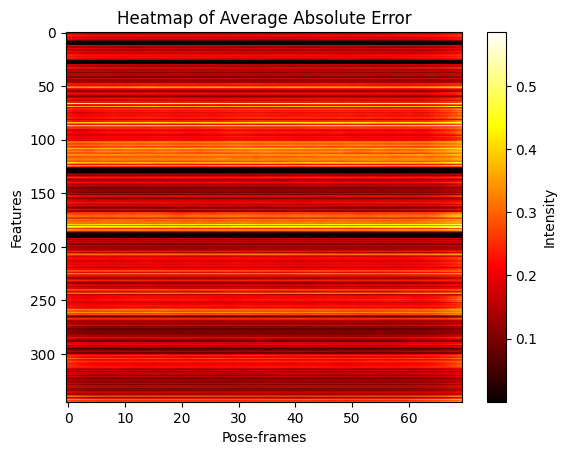

In [ ]:
import numpy as np

# Convert tensor to NumPy for plotting
matrix_np = avg_error_matrix.numpy()

matrix_np = np.rot90(matrix_np)

# Plot as heatmap 
plt.imshow(matrix_np, cmap='hot', aspect='auto')
plt.colorbar(label='Intensity')
plt.title('Heatmap of Average Absolute Error')
plt.xlabel('Pose-frames')
plt.ylabel('Features')
plt.show()

In [ ]:
matrix_np_backup = matrix_np.copy()

x = torch.from_numpy(matrix_np.copy()).float()  # Convert to tensor

collapsed = torch.sum(x, dim=0, keepdim=True)

# Plot
plt.imshow(collapsed, cmap='hot', aspect='auto')
plt.colorbar(label='Intensity')
plt.title('Heatmap of Average Absolute Error')
plt.xlabel('Pose-frames')
plt.ylabel('Features')
plt.show()

NameError: name 'matrix_np' is not defined